# Tạo dữ liệu giao dịch giả lập

In [17]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Parameters
n_customers = 300
n_transactions = 5000

# Generate customer IDs
customer_ids = np.random.choice(
    [f"C{str(i).zfill(4)}" for i in range(n_customers)],
    size=n_transactions,
    replace=True
)

# Generate transaction dates
transaction_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 365, size=n_transactions), unit="D"
)

# Generate transaction amounts
amounts = np.round(np.random.exponential(scale=50, size=n_transactions) + 10, 2)

# Create transaction table
df_txn = pd.DataFrame({
    "customer_id": customer_ids,
    "transaction_date": transaction_dates,
    "amount": amounts
})

df_txn.head()

,customer_id,transaction_date,amount
0,C0102,2025-04-27,90.64
1,C0270,2025-09-28,40.24
2,C0106,2025-09-15,65.52
3,C0071,2025-06-29,29.16
4,C0188,2025-06-21,34.00


In [18]:
df_txn.tail()

,customer_id,transaction_date,amount
4995,C0246,2025-03-11,79.31
4996,C0028,2025-11-09,26.11
4997,C0160,2025-12-30,34.04
4998,C0234,2025-09-11,33.49
4999,C0189,2025-05-24,24.00


In [19]:
print("Frequency: ", len(df_txn[df_txn['customer_id'] == "C0000"].sort_values(by="transaction_date")))
print("Monetary: ", df_txn[df_txn['customer_id'] == "C0000"]['amount'].sum())

df_txn[df_txn['customer_id'] == "C0000"].sort_values(by="transaction_date")

Frequency:  18
Monetary:  1020.4800000000001


,customer_id,transaction_date,amount
4935,C0000,2025-01-18,52.21
1685,C0000,2025-01-20,14.30
1639,C0000,2025-03-07,40.47
362,C0000,2025-03-11,74.00
536,C0000,2025-03-26,19.32
560,C0000,2025-04-07,102.67
2683,C0000,2025-04-16,14.30
2926,C0000,2025-06-02,75.72
4237,C0000,2025-06-13,79.81
2526,C0000,2025-07-17,93.69


# Tạo bảng RFM

Ý nghĩa:

- Recency: số ngày kể từ lần giao dịch gần nhất

- Frequency: số giao dịch

- Monetary: tổng tiền đã chi


In [20]:
# Snapshot date (ngày phân tích)
snapshot_date = df_txn["transaction_date"].max() + pd.Timedelta(days=1)
print("snapshot_date: ", snapshot_date)

rfm = (
    df_txn
    .groupby("customer_id")
    .agg({
        "transaction_date": lambda x: (snapshot_date - x.max()).days,
        "customer_id": "count",
        "amount": "sum"
    })
    .rename(columns={
        "transaction_date": "recency",
        "customer_id": "frequency",
        "amount": "monetary"
    })
    .reset_index()
)

rfm.head()


snapshot_date:  2026-01-01 00:00:00


,customer_id,recency,frequency,monetary
0,C0000,5,18,1020.48
1,C0001,18,15,1154.12
2,C0002,3,17,970.63
3,C0003,25,16,812.73
4,C0004,7,22,1094.56


# A. Quantile-Based RFM Score


## 1. Tính RFM theo quantile





In [21]:
rfm_q = rfm.copy()

# Recency: nhỏ tốt → score cao
rfm_q["R_score"] = pd.qcut(
    rfm_q["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency: lớn tốt
rfm_q["F_score"] = pd.qcut(
    rfm_q["frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary: lớn tốt
rfm_q["M_score"] = pd.qcut(
    rfm_q["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm_q[["customer_id", "R_score", "F_score", "M_score"]].head()


,customer_id,R_score,F_score,M_score
0,C0000,5,3,3
1,C0001,3,2,4
2,C0002,5,3,3
3,C0003,2,3,2
4,C0004,5,5,4


## 2. Segmentation theo RFM score

In [22]:
rfm_q["RFM_score"] = (
    rfm_q["R_score"].astype(str) +
    rfm_q["F_score"].astype(str) +
    rfm_q["M_score"].astype(str)
)

rfm_q[["customer_id", "RFM_score"]].head()

,customer_id,RFM_score
0,C0000,533
1,C0001,324
2,C0002,533
3,C0003,232
4,C0004,554


In [23]:
def rfm_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    if r >= 4 and f >= 3:
        return "Loyal Customers"

    if r >= 4 and f <= 2:
        return "New Customers"

    if r <= 2 and f >= 3:
        return "At Risk"

    if r <= 2 and f <= 2:
        return "Hibernating"

    return "Others"

rfm_q["rfm_segment"] = rfm_q.apply(rfm_segment, axis=1)
rfm_q[["customer_id", "RFM_score", "rfm_segment"]].head()

,customer_id,RFM_score,rfm_segment
0,C0000,533,Loyal Customers
1,C0001,324,Others
2,C0002,533,Loyal Customers
3,C0003,232,At Risk
4,C0004,554,Champions


In [24]:
rfm_q["rfm_segment"].value_counts()

rfm_segment
At Risk            62
Others             59
Hibernating        55
Champions          46
New Customers      41
Loyal Customers    37
Name: count, dtype: int64

## 3. Visualization – Heatmap theo RFM Segment

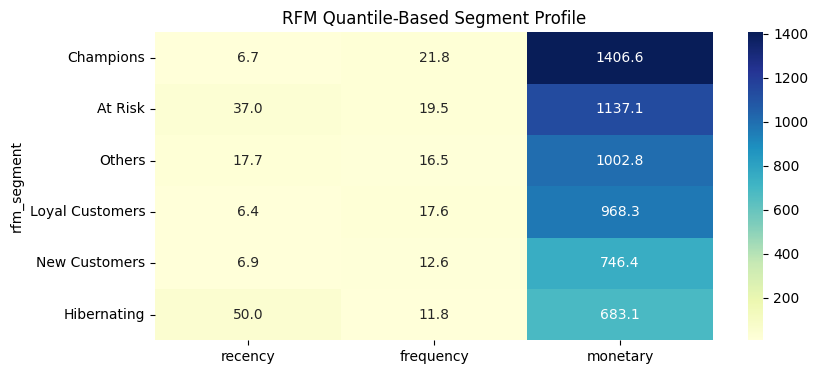

In [25]:
segment_profile_q = (
    rfm_q
    .groupby("rfm_segment")[["recency", "frequency", "monetary"]]
    .mean()
    .sort_values("monetary", ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
sns.heatmap(
    segment_profile_q,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("RFM Quantile-Based Segment Profile")
plt.show()


# KMeans RFM

## 1. Phân nhóm khách hàng theo RFM (KMeans)

### Chuẩn hóa feature

Vì scale rất khác nhau → cần chuẩn hóa trước khi clustering.

In [26]:
from sklearn.preprocessing import StandardScaler

features = ["recency", "frequency", "monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=[f"{c}_scaled" for c in features]
)

rfm_scaled_df.head()


,recency_scaled,frequency_scaled,monetary_scaled
0,-0.827865,0.295382,0.074864
1,-0.231619,-0.369227,0.461163
2,-0.919595,0.073845,-0.069233
3,0.089437,-0.147691,-0.525658
4,-0.736135,1.181528,0.288999


In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["segment"] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,customer_id,recency,frequency,monetary,segment
0,C0000,5,18,1020.48,0
1,C0001,18,15,1154.12,0
2,C0002,3,17,970.63,0
3,C0003,25,16,812.73,1
4,C0004,7,22,1094.56,0


## 2. Visualization – Heatmap RFM theo segment

In [28]:
segment_profile = (
    rfm
    .groupby("segment")[features]
    .mean()
)

segment_profile


,recency,frequency,monetary
segment,,,
0,18.485437,18.689320,1105.165146
1,17.931624,13.418803,751.436410
2,67.937500,12.000000,672.478750
3,15.395833,23.354167,1564.685625


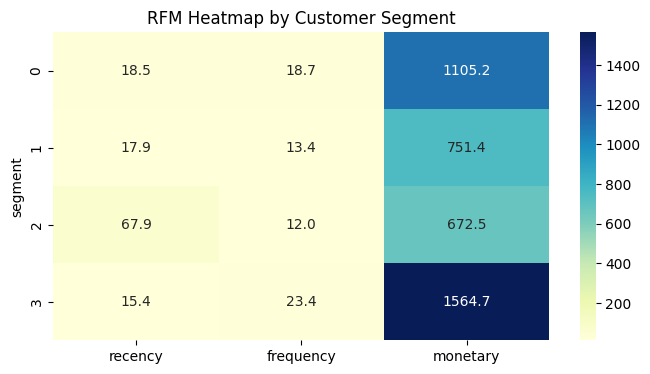

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(
    segment_profile,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("RFM Heatmap by Customer Segment")
plt.show()


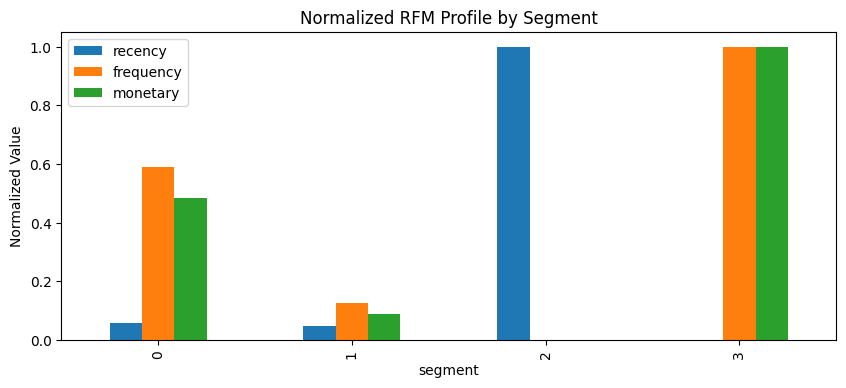

In [30]:
segment_profile_norm = (
    (segment_profile - segment_profile.min()) /
    (segment_profile.max() - segment_profile.min())
)

segment_profile_norm.plot(
    kind="bar",
    figsize=(10, 4)
)

plt.title("Normalized RFM Profile by Segment")
plt.ylabel("Normalized Value")
plt.show()


# C. So sánh: Clustering vs RFM Score

In [31]:
pd.crosstab(
    rfm["segment"],          # KMeans segment
    rfm_q["rfm_segment"]     # RFM rule-based
)

rfm_segment,At Risk,Champions,Hibernating,Loyal Customers,New Customers,Others
segment,,,,,,
0,34,19,1,28,1,20
1,11,0,26,9,40,31
2,4,0,28,0,0,0
3,13,27,0,0,0,8
